ECC — Elliptic Curve Cryptography

Эллиптическая кривая описывается графиком функции вида: y^2 = x^3 + ax + b  
Чтобы кривая была гладкой (без самопересечений и острых точек), должно выполняться условие: 4a^3 + 27b^2 !≡ 0(mod p)

Рассмотрим кривую secp256k1, Bitcoin имеющую вид: y^2 = x^3 + 7

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import random

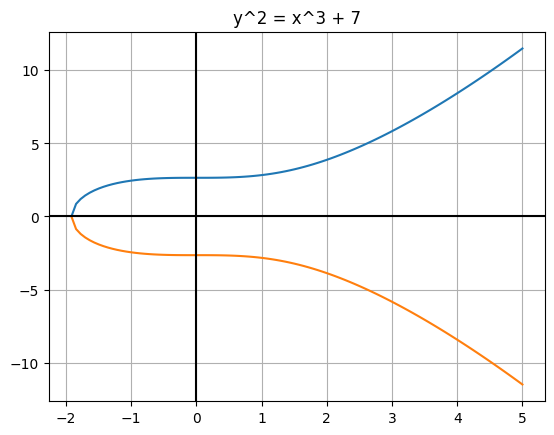

In [45]:
# Построим график функции y = ± sqrt(x^3 + 7)
# Исключим корень из отрицательного числа, поэтому x^3 + 7 ≥ 0
# x ≥ −7^(1/3) ​≈ −1.9129
x = np.linspace(-1.9129, 5, 100)  # массив из 100 равномерно распределённых значений от -1.9129 до 5
y = np.sqrt(x**3 + 7)

plt.plot(x, y)
plt.plot(x, -y)

plt.axhline(0, color='black')   # ось X
plt.axvline(0, color='black')   # ось Y
plt.grid(True)
plt.title("y^2 = x^3 + 7")
plt.show()

In [46]:
# Точки кривой над 𝐹p
# Перебираем x=0..p-1 и ищем y, такие что y^2 ≡ x^3 + 7 (mod p)

p = 17  # В реальной жизни p = 2^256
a = 0
points_x = []
points_y = []

for x in range(p):
    rhs = (x**3 + 7) % p  # right‑hand side правая часть уравнения    

    for y in range(p):
        lhs = (y*y) % p  # left‑hand side левая часть уравнения
        if lhs == rhs:  
            points_x.append(x)
            points_y.append(y)

print(f"Точки на кривой y^2 ≡ x^3 + 7 (mod {p}):")
for x, y in zip(points_x, points_y):
    print(f"({x}, {y})", end=' ')

print("\nВсего точек:", len(points_x), "+ точка O на бесконечности")

Точки на кривой y^2 ≡ x^3 + 7 (mod 17):
(1, 5) (1, 12) (2, 7) (2, 10) (3, 0) (5, 8) (5, 9) (6, 6) (6, 11) (8, 3) (8, 14) (10, 2) (10, 15) (12, 1) (12, 16) (15, 4) (15, 13) 
Всего точек: 17 + точка O на бесконечности


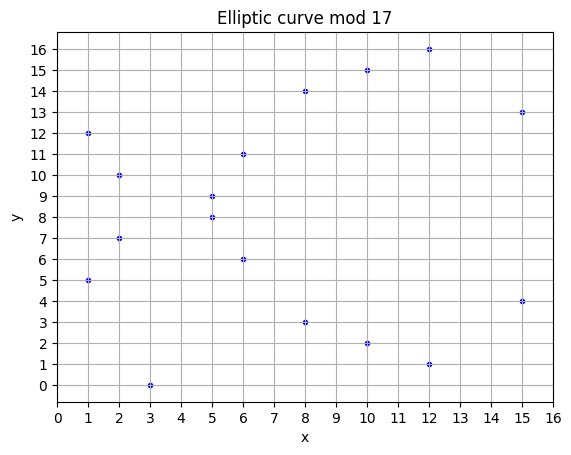

In [47]:
# Отобразим точки на кривой y^2 ≡ x^3 + 7 (mod {p}) на графике
plt.title(f"Elliptic curve mod {p}")
plt.scatter(points_x, points_y,  marker='.', color='blue')
plt.xticks(np.arange(0, 17, 1))
plt.yticks(np.arange(0, 17, 1))
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Базовые групповые операции в группе точек эллиптической кривой

In [48]:
# Отрицание точки
def point_neg(P: tuple[int, int]):
    if P is None:
        return None
    x, y = P
    return (x, (-y) % p)

In [49]:
# Проверка принадлежит ли точка кривой
def is_on_curve(P):
    if P is None:
        return True

    x, y = P
    return (y*y - (x*x*x + a*x + 7)) % p == 0

In [50]:
# Сложение двух точек на кривой
def point_add(P: Optional[Tuple[int, int]], 
              Q: Optional[Tuple[int, int]]):
    if P is None:
        return Q
    if Q is None:
        return P

    x1, y1 = P
    x2, y2 = Q

    # P + (-P) = O
    if x1 == x2 and (y1 + y2) % p == 0:
        return None

    if P != Q:
        # λ = (y2 - y1) / (x2 - x1)
        num = (y2 - y1) % p
        den = (x2 - x1) % p
    else:
        # удвоение: λ = (3x1^2 + a) / (2y1)
        num = (3 * x1 * x1 + a) % p  # numerator числитель
        den = (2 * y1) % p           # denominator знаменатель

    # в трёхаргументном pow(a, b, p) отрицательная степень — это не обычное возведение в степень, 
    # Python интерпретирует это как модульную обратную:
    # a * x ≡ 1 (mod p)
    # т. о. обратный элемент к den по модулю p
    inv_den = pow(den, -1, p)

    lamda = (num * inv_den) % p  # коэффициента наклона прямой, который используется при сложении точек на эллиптической кривой

    # x3 = λ^2 − x1 − x2 (mod p)
    x3 = (lamda * lamda - x1 - x2) % p
    # y3 = λ(x1 − x3) − y1 (mod p)
    y3 = (lamda * (x1 - x3) - y1) % p

    return (x3, y3)

In [51]:
# Примера работы point_add
G = (1, 5)
print("G =", G)
print("2G =", point_add(G, G))
print("G + 2G =", point_add(G, point_add(G, G)))

G = (1, 5)
2G = (2, 10)
G + 2G = (5, 9)


In [52]:
# Умножение точки на скаляр
# Это ключевая операция в ECC.
# Мы будем использовать алгоритм double-and-add (удвоение и добавление), потому что он быстрый и простой.
def scalar_mul(k: int, P):
    result = None  # это будет O
    addend = P     # текущая добавляемая точка

    while k > 0:
        if k & 1:  # если младший бит = 1
            result = point_add(result, addend)

        addend = point_add(addend, addend)  # удвоение
        k >>= 1  # сдвиг вправо (деление на 2)

    return result

In [53]:
# Примера работы scalar_mul
G = (1, 5)
print("G =", G)
print("2G =", scalar_mul(2, G))
print("3G =", scalar_mul(3, G))
print("4G =", scalar_mul(4, G))
print("5G =", scalar_mul(5, G))

G = (1, 5)
2G = (2, 10)
3G = (5, 9)
4G = (12, 1)
5G = (12, 16)


In [54]:
# Проверка порядка точки
def point_order(P, logging = False):
    Q = P
    n = 1
    while Q is not None:
        curr_point = Q if Q is not None else P
        if logging:
            print(n, curr_point)
        Q = point_add(Q, P)
        n += 1
    if logging:
        print(n, f"{P} вернулись в изначальную точку G")
    return n

In [55]:
# Подгруппы точек
processed = set()   # точки, которые уже принадлежат найденным подгруппам
unique_groups = []  # список уникальных подгрупп (точка + порядок)

for x, y in zip(points_x, points_y):
    P = (x, y)

    # если точка уже в обработанной подгруппе — пропускаем
    if P in processed:
        continue

    # вычисляем порядок точки
    n = point_order(P)

    # добавляем подгруппу в processed
    subgroup = set()
    Q = None
    for k in range(n):
        Q = scalar_mul(k, P)
        if Q is not None:
            subgroup.add(Q)

    processed |= subgroup  # объединяем множества

    # сохраняем уникальную подгруппу
    unique_groups.append((P, n))


for P, n in unique_groups:
    print(P, "Порядок группы:", n)

(1, 5) Порядок группы: 9
(3, 0) Порядок группы: 2
(6, 6) Порядок группы: 18


Для примера посмотрим группы точек по модулю 17

In [56]:
# Базовая точка
G = (1, 5)  # Порядок группы: 9
print(f"Порядок точки: {point_order(G, True)}")

1 (1, 5)
2 (2, 10)
3 (5, 9)
4 (12, 1)
5 (12, 16)
6 (5, 8)
7 (2, 7)
8 (1, 12)
9 (1, 5) вернулись в изначальную точку G
Порядок точки: 9


In [57]:
# Базовая точка
G = (3, 0)  # Порядок группы: 2
print(f"Порядок группы: {point_order(G, True)}")

1 (3, 0)
2 (3, 0) вернулись в изначальную точку G
Порядок группы: 2


In [58]:
# Базовая точка
G = (6, 6)  # Порядок группы: 18
print(f"Порядок группы: {point_order(G, True)}")

1 (6, 6)
2 (1, 5)
3 (8, 14)
4 (2, 10)
5 (10, 15)
6 (5, 9)
7 (15, 4)
8 (12, 1)
9 (3, 0)
10 (12, 16)
11 (15, 13)
12 (5, 8)
13 (10, 2)
14 (2, 7)
15 (8, 3)
16 (1, 12)
17 (6, 11)
18 (6, 6) вернулись в изначальную точку G
Порядок группы: 18


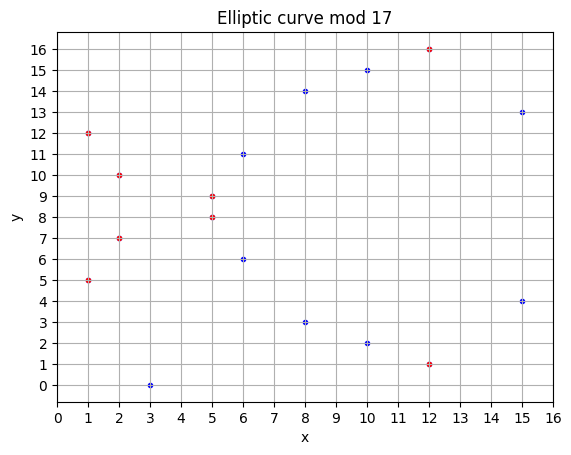

In [59]:
# Отметим на графике красным цветом точки принадлежащие группе G = (1, 5)
points_x2 = []
points_y2 = []

G = (1, 5)
Q = G
while Q is not None:
    x, y = Q
    points_x2.append(x) 
    points_y2.append(y)
    Q = point_add(Q, G)


plt.title(f"Elliptic curve mod {p}")
plt.scatter(points_x, points_y,  marker='.', color='blue')
plt.scatter(points_x2, points_y2,  marker='.', color='red')
plt.xticks(np.arange(0, 17, 1))
plt.yticks(np.arange(0, 17, 1))
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

ECDH (Elliptic Curve Diffie–Hellman)

In [60]:
G = (1, 5)
# G = (points_x[0], points_y[0])
print("Базовая точка G:", G)

Базовая точка G: (1, 5)


In [61]:
# секретные ключи
alice_private = random.randint(1, 20)
bob_private = random.randint(1, 20)

print("Alice private:", alice_private)
print("Bob private:", bob_private)

# публичные ключи
alice_public = scalar_mul(alice_private, G)
bob_public = scalar_mul(bob_private, G)

print("Alice public:", alice_public)
print("Bob public:", bob_public)

Alice private: 17
Bob private: 19
Alice public: (1, 12)
Bob public: (1, 5)


In [62]:
alice_shared = scalar_mul(alice_private, bob_public)
bob_shared = scalar_mul(bob_private, alice_public)

print("Alice shared:", alice_shared)
print("Bob shared:", bob_shared)

Alice shared: (1, 12)
Bob shared: (1, 12)
